In [1]:
import pyuff

# Открываем UFF файл (аналог readuff в MATLAB)
uff_file = pyuff.UFF('/Users/bogda/Desktop/Acoustics/Scientific/Исходные данные/Seismic/Recording-2.uff')

# Узнаем, какие типы наборов данных есть в файле
# (аналог Info.dsTypes из MATLAB)
типы_наборов = uff_file.get_set_types()
print(f"Типы наборов данных в файле: {типы_наборов}")

Типы наборов данных в файле: [58  0]


In [ ]:
# Читаем все наборы данных из файла
# (аналог UffDataSets из MATLAB)
все_данные = uff_file.read_sets()

# Данные возвращаются в виде списка словарей (list of dicts)
# Каждый словарь соответствует одному набору данных

In [ ]:
import numpy as np
# Предположим, что четвертый набор данных (индекс 3) - это тип 58
dataset_58 = все_данные[0]

# Проверим, что это действительно тип 58
if dataset_58['type'] == 58:
    # Основные поля: 'x' (ось абсцисс) и 'data' (значения)
    # (аналог UffDataSets{i}.x и UffDataSets{i}.measData)
    частоты = dataset_58['x']
    комплексная_чх = dataset_58['data']

    print(f"Форма данных: {комплексная_чх.shape}")
    print(f"Диапазон частот: от {частоты[0]} до {частоты[-1]} Гц")
    
    # Можно, например, построить график
    import matplotlib.pyplot as plt
    plt.semilogy(частоты, np.abs(комплексная_чх))
    plt.xlabel('Частота [Гц]')
    plt.ylabel('Модуль ЧХ')
    plt.show()

Форма данных: (147654656,)
Диапазон частот: от 0.0 до 18024.203735850002 Гц


OverflowError: Exceeded cell block limit in Agg.  Please set the value of rcParams['agg.path.chunksize'], (currently 0) to be greater than 100 or increase the path simplification threshold(rcParams['path.simplify_threshold'] = 0.111111111111 by default and path.simplify_threshold = 0.111111111111 on the input).

<Figure size 640x480 with 1 Axes>

In [ ]:
import pyuff
import numpy as np
import matplotlib.pyplot as plt

# 1. ЧИТАЕМ ФАЙЛ
# ==============
print("Читаем UFF файл...")
uff_file = pyuff.UFF('/Users/bogda/Desktop/Acoustics/Scientific/Исходные данные/Seismic/Recording-2.uff')  # Укажите путь к вашему файлу

# Проверяем типы наборов данных
типы = uff_file.get_set_types()
print(f"Типы наборов в файле: {типы}")

# Читаем все данные
все_данные = uff_file.read_sets()

# 2. ИЩЕМ ВСЕ НАБОРЫ ТИПА 58
# ===========================
print("\nОбрабатываем данные типа 58...")

for idx, dataset in enumerate(все_данные):
    if dataset['type'] == 58:
        print(f"\n--- Набор данных #{idx+1} (тип 58) ---")
        
        # Извлекаем метаданные
        описание = dataset.get('d1', 'Нет описания').strip()
        print(f"Описание: {описание}")
        
        # Получаем данные
        x_данные = dataset['x']        # Это может быть частота или время
        y_данные = dataset['data']      # Измеренные данные
        
        print(f"Форма данных: {y_данные.shape}")
        print(f"Тип данных: {'комплексные' if np.iscomplexobj(y_данные) else 'вещественные'}")
        
        # 3. ОПРЕДЕЛЯЕМ, ЧТО У НАС: ВРЕМЯ ИЛИ ЧАСТОТА
        # ===========================================
        
        # Тип функции (functionType) определяет, что это за данные
        # По документации UFF:
        # 1 = Time Response (временной отклик) - это наш случай!
        тип_функции = dataset.get('funcType', 0)  # funcType или functionType
        
        # Также можно проверить по полю 'abscUnitsLabel' - единицы оси X
        единицы_x = dataset.get('abscUnitsLabel', '').strip()
        
        print(f"Тип функции (funcType): {тип_функции}")
        print(f"Единицы оси X: '{единицы_x}'")
        
        # Это временной сигнал, если:
        # 1) funcType == 1 (Time Response) ИЛИ
        # 2) единицы_x содержат 's', 'sec', 'time' ИЛИ
        # 3) ось X равномерно растет, но нет отрицательных значений (частота не может быть отриц.)
        
        is_time_signal = False
        
        if тип_функции == 1:
            is_time_signal = True
            print("✓ funcType=1: это временной сигнал")
        elif any(ед in единицы_x.lower() for ед in ['s', 'sec', 'time', 'сек']):
            is_time_signal = True
            print(f"✓ Единицы '{единицы_x}' указывают на время")
        elif all(x_данные >= 0) and len(x_данные) > 1 and x_данные[1] - x_данные[0] > 0:
            # Если все x >= 0 и монотонно растут - это может быть время или частота
            # Нужно проверить диапазон
            if x_данные[-1] < 1000:  # Если последнее значение < 1000, скорее время, чем частота
                is_time_signal = True
                print("✓ Похоже на временной сигнал (маленькие значения)")
        
        # 4. СТРОИМ ГРАФИК
        # ================
        if is_time_signal:
            plt.figure(figsize=(12, 6))
            
            # Проверяем, комплексные ли данные
            if np.iscomplexobj(y_данные):
                # Для комплексных данных показываем и амплитуду, и фазу (или реальную/мнимую части)
                plt.subplot(2, 1, 1)
                plt.plot(x_данные, np.real(y_данные), 'b-', label='Реальная часть', linewidth=0.8)
                plt.plot(x_данные, np.imag(y_данные), 'r-', label='Мнимая часть', linewidth=0.8)
                plt.ylabel('Амплитуда')
                plt.legend()
                plt.grid(True, alpha=0.3)
                plt.title(f'Временной сигнал #{idx+1}: {описание}')
                
                plt.subplot(2, 1, 2)
                plt.plot(x_данные, np.abs(y_данные), 'g-', label='Модуль', linewidth=1)
                plt.xlabel('Время [сек]')
                plt.ylabel('Модуль')
                plt.legend()
                plt.grid(True, alpha=0.3)
            else:
                # Для вещественных данных - простой график
                plt.plot(x_данные, y_данные, 'b-', linewidth=0.8)
                plt.xlabel('Время [сек]')
                plt.ylabel('Амплитуда')
                plt.title(f'Временной сигнал #{idx+1}: {описание}')
                plt.grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.show()
            
            # 5. ВЫВОДИМ ОСНОВНЫЕ ХАРАКТЕРИСТИКИ СИГНАЛА
            # ===========================================
            dt = x_данные[1] - x_данные[0]  # Шаг по времени
            fs = 1/dt if dt > 0 else 0       # Частота дискретизации
            длительность = x_данные[-1] - x_данные[0]
            
            print(f"\nХарактеристики сигнала:")
            print(f"  Длительность: {длительность:.4f} сек")
            print(f"  Шаг дискретизации (dt): {dt:.6f} сек")
            print(f"  Частота дискретизации (fs): {fs:.1f} Гц")
            print(f"  Количество точек: {len(y_данные)}")
            
            if np.iscomplexobj(y_данные):
                print(f"  Макс. амплитуда (модуль): {np.max(np.abs(y_данные)):.4f}")
            else:
                print(f"  Макс. значение: {np.max(y_данные):.4f}")
                print(f"  Мин. значение: {np.min(y_данные):.4f}")
                print(f"  Размах: {np.ptp(y_данные):.4f}")
        else:
            print("✗ Это НЕ временной сигнал, вероятно, частотная характеристика")
            print("  (используйте другой скрипт для построения ЧХ)")

# 6. ПОЛЕЗНАЯ ИНФОРМАЦИЯ О ДОСТУПНЫХ ПОЛЯХ
# =========================================
print("\n--- Доступные поля в первом наборе данных ---")
if len(все_данные) > 0:
    for ключ, значение in все_данные[0].items():
        if ключ not in ['data', 'x']:  # Не показываем большие массивы
            print(f"  {ключ}: {значение}")

Читаем UFF файл...
Типы наборов в файле: [58 58]

Обрабатываем данные типа 58...

--- Набор данных #1 (тип 58) ---
Описание: Нет описания
Форма данных: (147654656,)
Тип данных: вещественные
Тип функции (funcType): 0
Единицы оси X: ''
✗ Это НЕ временной сигнал, вероятно, частотная характеристика
  (используйте другой скрипт для построения ЧХ)

--- Набор данных #2 (тип 58) ---
Описание: Нет описания
Форма данных: (147654656,)
Тип данных: вещественные
Тип функции (funcType): 0
Единицы оси X: ''
✗ Это НЕ временной сигнал, вероятно, частотная характеристика
  (используйте другой скрипт для построения ЧХ)

--- Доступные поля в первом наборе данных ---
  type: 58
  binary: 0
  id1: Signal 1
  id2: NONE
  id3: 11-Mar-26 20:37:18
  id4: NONE
  id5: Output Group
  func_type: 1
  func_id: 0
  ver_num: 0
  load_case_id: 0
  rsp_ent_name: NONE
  rsp_node: 0
  rsp_dir: 0
  ref_ent_name: NONE
  ref_node: 0
  ref_dir: 0
  ord_data_type: 2
  num_pts: 147654656
  abscissa_spacing: 1
  abscissa_min: 0.0


FS: 16384 Гц, Длительность: 0.9 ч, Сегментов: 51
1/12 октавных полос: 189 (0.10 - 8000.0 Гц)


Обработка: 100%|██████████| 51/51 [00:01<00:00, 29.57it/s]


Валидных сегментов: 51/51


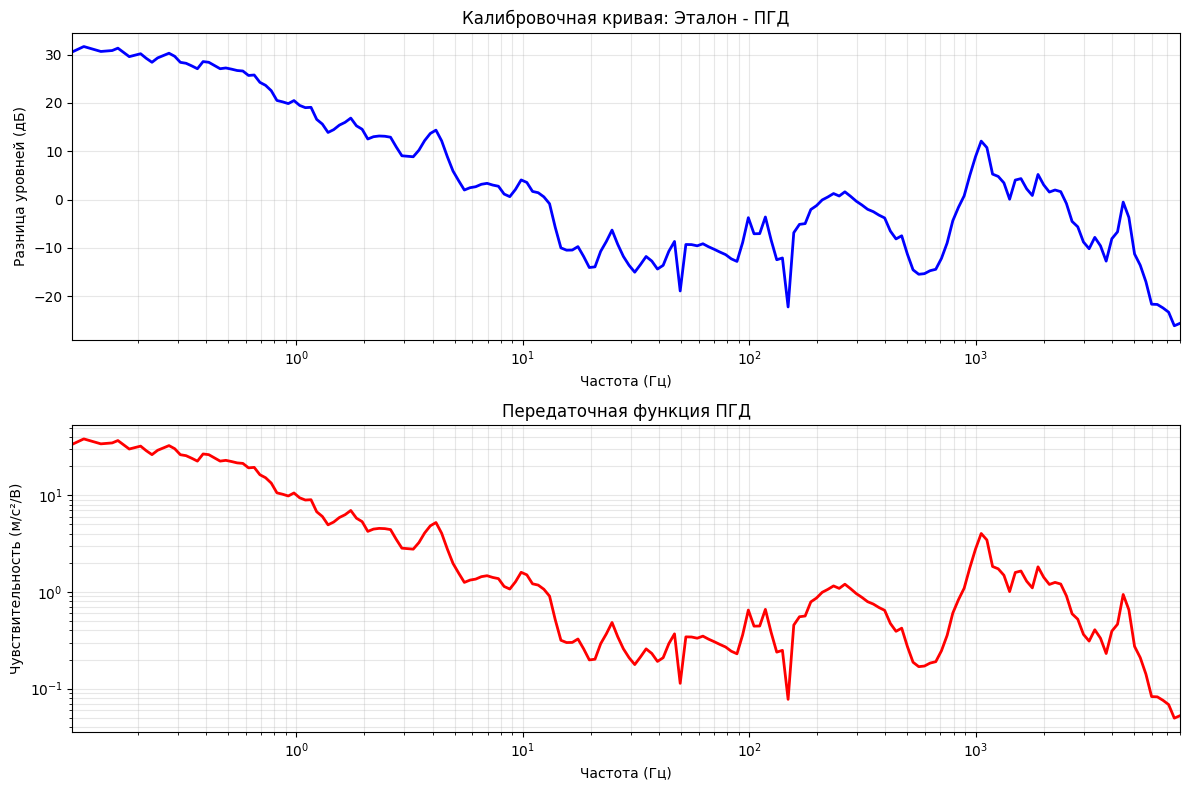


Результаты сохранены в calibration.txt

Первые 5 частотных полос:
0.103 Гц: 30.59 дБ, 3.384e+01 м/с²/В
0.115 Гц: 31.68 дБ, 3.838e+01 м/с²/В
0.137 Гц: 30.66 дБ, 3.412e+01 м/с²/В
0.154 Гц: 30.85 дБ, 3.489e+01 м/с²/В
0.163 Гц: 31.34 дБ, 3.691e+01 м/с²/В


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from tqdm import tqdm

def calibrate_from_ambient_noise(wav_file, segment_duration=60, plot=True):
    
    # 1. Чтение данных
    fs, data = wavfile.read(wav_file)
    
    ref = data[:, 0] - np.mean(data[:, 0])
    cal = data[:, 1] - np.mean(data[:, 1])
    
    # 2. Параметры обработки
    seg_samples = int(segment_duration * fs)
    n_segments = len(ref) // seg_samples
    
    print(f"FS: {fs} Гц, Длительность: {len(ref)/fs/3600:.1f} ч, Сегментов: {n_segments}")
    
    # 3. Расчет 1/12 октавных частот
    ref_freq = 1000.0
    n_min = int(12 * np.log2(0.1 / ref_freq))
    n_max = int(12 * np.log2((fs/2) / ref_freq))
    f_centers = ref_freq * (2 ** (np.arange(n_min, n_max + 1) / 12))
    
    # 4. Подготовка масок для фильтрации
    nfft = seg_samples 
    freqs = np.fft.rfftfreq(nfft, 1/fs)
    
    filters = []
    valid_freqs = []
    for fc in f_centers:
        f_low = fc / 2**(1/24)
        f_high = fc * 2**(1/24)
        mask = (freqs >= f_low) & (freqs < f_high)
        if np.any(mask):
            filters.append(mask)
            valid_freqs.append(fc)
    
    n_bands = len(filters)
    print(f"1/12 октавных полос: {n_bands} ({valid_freqs[0]:.2f} - {valid_freqs[-1]:.1f} Гц)")
    
    # 5. Накопление спектров
    ref_power_sum = np.zeros(n_bands)
    cal_power_sum = np.zeros(n_bands)
    valid_segments = 0
    
    for i in tqdm(range(n_segments), desc="Обработка"):
        start = i * seg_samples
        ref_seg = ref[start:start + seg_samples]
        cal_seg = cal[start:start + seg_samples]
        
        ref_fft = np.fft.rfft(ref_seg)
        cal_fft = np.fft.rfft(cal_seg)
        
        # Спектр мощности
        ref_power = np.abs(ref_fft)**2 / seg_samples
        cal_power = np.abs(cal_fft)**2 / seg_samples
        
        # Усреднение по октавным полосам
        for j, mask in enumerate(filters):
            if np.any(mask):
                ref_power_sum[j] += np.mean(ref_power[mask])
                cal_power_sum[j] += np.mean(cal_power[mask])
        
        valid_segments += 1
    
    print(f"Валидных сегментов: {valid_segments}/{n_segments}")
    
    # 6. Усреднение
    ref_power_avg = ref_power_sum / valid_segments
    cal_power_avg = cal_power_sum / valid_segments
    
    # Разница уровней в дБ
    calibration_db = 10 * np.log10(ref_power_avg / cal_power_avg)
    
    # Чувствительность
    sensitivity = np.sqrt(ref_power_avg / cal_power_avg)
    
    
    
    if plot:
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
        
        ax1.semilogx(valid_freqs, calibration_db, 'b-', linewidth=2)
        ax1.grid(True, alpha=0.3, which='both')
        ax1.set_xlabel('Частота (Гц)')
        ax1.set_ylabel('Разница уровней (дБ)')
        ax1.set_title('Калибровочная кривая: Эталон - ПГД')
        ax1.set_xlim([valid_freqs[0], valid_freqs[-1]])
        
        ax2.semilogx(valid_freqs, sensitivity, 'r-', linewidth=2)
        ax2.grid(True, alpha=0.3, which='both')
        ax2.set_xlabel('Частота (Гц)')
        ax2.set_ylabel('Чувствительность (м/с²/В)')
        ax2.set_title('Передаточная функция ПГД')
        ax2.set_yscale('log')
        ax2.set_xlim([valid_freqs[0], valid_freqs[-1]])
        
        plt.tight_layout()
        plt.savefig('calibration.png', dpi=150)
        plt.show()
    
    print(f"\nРезультаты сохранены в calibration.txt")
    return np.array(valid_freqs), calibration_db, sensitivity

# Использование
if __name__ == "__main__":
    freqs, cal_db, sens = calibrate_from_ambient_noise('/Users/bogda/Desktop/Acoustics/Scientific/Исходные данные/Seismic/Recording-1.wav', segment_duration=60)
    
    print("\nПервые 5 частотных полос:")
    for i in range(min(5, len(freqs))):
        print(f"{freqs[i]:.3f} Гц: {cal_db[i]:.2f} дБ, {sens[i]:.3e} м/с²/В")